Loading dataset /home/user/proj/mentor/cayleypy-cube/experiments/datasets/cube_3x3_labeled.pt
Dataset loaded:
  Total states: 40
  Solved states: 40
  Solve rate: 100.00%


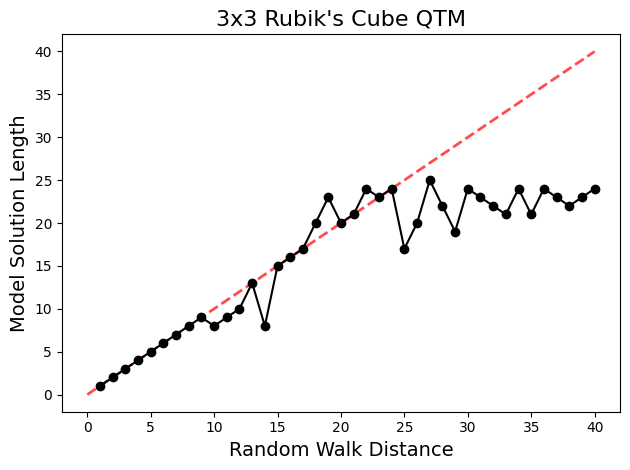

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("/home/user/proj/mentor/cayleypy-cube/scripts/plots.ipynb"))))


def load_dataset(dataset_path):
    print(f"Loading dataset {dataset_path}")
    data = torch.load(dataset_path, map_location="cpu")

    print("Dataset loaded:")
    print(f"  Total states: {len(data['states'])}")
    print(f"  Solved states: {data['solved_flags'].sum().item()}")
    print(f"  Solve rate: {data['solved_flags'].float().mean().item():.2%}")

    return data


def make_plot(data):
    """Create scatter plot of K vs optimal length."""
    walk_distances = data["walk_distances"].numpy()
    found_lengths = data["found_lengths"].numpy()

    # only solved states
    solved_mask = found_lengths >= 0
    K_solved = walk_distances[solved_mask]
    optimal_solved = found_lengths[solved_mask]

    plt.scatter(K_solved, optimal_solved, alpha=0.6, s=20, c=K_solved)

    max_val = max(K_solved.max(), optimal_solved.max())
    plt.plot(
        [0, max_val], [0, max_val], "r--", alpha=0.7, linewidth=2, label="K = Optimal"
    )

    unique_K = np.unique(K_solved)
    mean_optimal = [optimal_solved[K_solved == k].mean() for k in unique_K]
    plt.plot(
        unique_K,
        mean_optimal,
        "k-",
        label="Mean Optimal Length",
        marker="o",
    )

    plt.xlabel("Random Walk Distance", fontsize=14)
    plt.ylabel("Model Solution Length", fontsize=14)
    plt.title(
        "3x3 Rubik's Cube QTM",
        fontsize=16,
    )

    plt.tight_layout()
    plt.show()



data = load_dataset("/home/user/proj/mentor/cayleypy-cube/experiments/datasets/cube_3x3_labeled.pt")

make_plot(data)


